In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# GRAPE Dataset – Visual Field Synthesis
## Conditional Diffusion Probabilistic Model (CDPM)

**Architecture overview**

```
Fundus Image ──► FundusViTEncoder (ViT-B/16)  ──► 768-d image embedding  ──┐
                                                                              ├──► ConditioningFusion ──► 896-d cond ──► VFDenoiser (1-D UNet)
[Age, Gender, IOP, CCT] ──► ClinicalMLP ──────► 128-d clinical embedding ──┘                                                    │
                                                                                                                    Synthesised 61-point VF
```

| Split | Fraction | Purpose |
|-------|----------|---------|
| Train | **70 %** | Train CDPM weights |
| Test  | **30 %** | Synthesise VFs, compute metrics |

> **Data source:** GRAPE Baseline sheet · Image filenames from Col Q · VF values from Cols T–CB (61 points) · Clinical covariates from Cols C, D, E, F  
> **Ignored:** Cols G–K, R–S, Follow-up sheet


## Contrastive Loss (User Defined)
This cell defines a contrastive loss to be combined with diffusion loss.
Total Loss = Diffusion Loss + λ * Contrastive Loss

## Section 0 – Install & Import Dependencies

In [2]:
# Install required packages (run once)
import subprocess, sys
pkgs = ["torch", "torchvision", "timm", "scikit-learn", "openpyxl",
        "pandas", "Pillow", "numpy", "tqdm", "matplotlib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)


0

In [3]:
import os, csv, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
import timm
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

# Try importing TPU (torch_xla)
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    TPU_AVAILABLE = True
except:
    TPU_AVAILABLE = False

# Device selection logic
if TPU_AVAILABLE:
    device = xm.xla_device()
    device_name = "TPU"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = f"GPU – {torch.cuda.get_device_name(0)}"
else:
    device = torch.device("cpu")
    device_name = "CPU"

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device_name}")

PyTorch  : 2.10.0+cu128
Device   : GPU – Tesla T4


## Section 1 – Configuration
Edit the paths and hyper-parameters here before running the notebook.

In [34]:
from pathlib import Path
import torch
import os

class Config:

    # ── Base folder in Google Drive ────────────────────────────────────────
    BASE_PATH = Path("/content/drive/MyDrive/fundusproject")

    # ── File paths ─────────────────────────────────────────────────────────
    EXCEL_PATH = BASE_PATH / "VF_and_clinical_information.xlsx"
    IMAGE_DIR = BASE_PATH / "Annotated images"

    CHECKPOINT_DIR = BASE_PATH / "checkpoints"
    RESULTS_DIR = BASE_PATH / "test_results"

    SHEET_NAME = "Baseline"

    # ── Excel column indices (0-based, after pandas reads header row 1) ────
    COL_AGE = 3        # C – Age
    COL_GENDER = 4     # D – Gender
    COL_IOP = 5        # E – IOP
    COL_CCT = 6        # F – CCT
    COL_CFP = 17       # Q – Fundus image filename

    # Cols G–K (6–10) and R–S (17–18) are intentionally ignored
    COL_VF_START = 20  # T – first VF point
    COL_VF_END = 81    # CB – last VF point → 61 values

    # ── Model dimensions ────────────────────────────────────────────────────
    VIT_MODEL = "vit_base_patch16_224"
    VIT_EMBED_DIM = 768

    CLINICAL_DIM = 4
    MLP_HIDDEN = 128
    MLP_EMBED_DIM = 128

    COND_DIM = VIT_EMBED_DIM + MLP_EMBED_DIM
    VF_DIM = 61

    # ── Diffusion schedule ──────────────────────────────────────────────────
    T_STEPS = 1000
    BETA_START = 5e-5
    BETA_END = 0.01

    # ── Training ────────────────────────────────────────────────────────────
    BATCH_SIZE = 8
    EPOCHS = 250
    LR = 1e-4
    TRAIN_RATIO = 0.70
    RANDOM_SEED = 42

    IMAGE_SIZE = 224
    NUM_WORKERS = 2

    LAMBDA_CONTRAST = 0.1

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()

# Create folders in Google Drive
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

print("Config ready. Device:", cfg.DEVICE)

Config ready. Device: cuda


## Section 2 – Input Reading

This section:
- **(2a)** Reads the `Baseline` sheet (header on Excel row 2)
- **(2b)** Resolves each image filename from **Col Q** to a full file path  
- **(2c)** Extracts the **61 VF values** from Cols T–CB  
- **(2d)** Extracts the **4 clinical covariates** – Age (C), Gender (D), IOP (E), CCT (F)  
- **(2e)** Z-score normalises using statistics computed **only from the training split** (no leakage)


In [5]:
class GRAPEDataset(Dataset):
    """
    Parses the GRAPE Baseline sheet.

    Each __getitem__ returns:
    img  : FloatTensor (3, IMAGE_SIZE, IMAGE_SIZE)
    clin : FloatTensor (4,) – z-scored [Age, Gender, IOP, CCT]
    vf   : FloatTensor (61,) – z-scored VF values (target)
    meta : dict {excel_row, cfp_name, raw_clinical, raw_vf}
    """

    GENDER_MAP = {
        "M": 0.0, "Male": 0.0, "male": 0.0, "m": 0.0,
        "F": 1.0, "Female": 1.0, "female": 1.0, "f": 1.0,
    }

    def __init__(self, excel_path: str, image_dir: str):

        self.image_dir = Path(image_dir)

        # Image transform
        self.img_transform = self._build_transform()

        # Parse Excel
        self.records = self._parse_excel(excel_path)

        print(f"[INPUT READING] {len(self.records)} valid samples from '{excel_path}'")

        # Normalisation stats (injected later)
        self.clin_mean = None
        self.clin_std = None
        self.vf_mean = None
        self.vf_std = None


    @staticmethod
    def _build_transform():
        return transforms.Compose([
            transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])


    def _parse_excel(self, excel_path: str) -> list:

        df = pd.read_excel(excel_path, sheet_name=cfg.SHEET_NAME, header=0)

        records = []

        for row_idx, row in df.iterrows():

            vals = row.tolist()

            # Image filename
            cfp = vals[cfg.COL_CFP - 1]

            if pd.isna(cfp) or str(cfp).strip() == "":
                continue

            img_path = self.image_dir / str(cfp).strip()

            if not img_path.exists():
                continue

            # Extract VF values
            vf_raw = vals[cfg.COL_VF_START - 1 : cfg.COL_VF_END - 1]

            if len(vf_raw) < cfg.VF_DIM:
                continue

            vf = []

            for v in vf_raw[:cfg.VF_DIM]:
                try:
                    fv = float(v)
                    vf.append(0.0 if np.isnan(fv) else fv)
                except (TypeError, ValueError):
                    vf.append(0.0)

            # Clinical features
            try:

                age = float(vals[cfg.COL_AGE - 1])

                gender = float(
                    self.GENDER_MAP.get(
                        str(vals[cfg.COL_GENDER - 1]).strip(),
                        0.0
                    )
                )

                iop = float(vals[cfg.COL_IOP - 1])
                cct = float(vals[cfg.COL_CCT - 1])

            except (TypeError, ValueError):
                continue

            records.append({
                "img_path": img_path,
                "cfp_name": str(cfp).strip(),
                "excel_row": row_idx + 2,
                "raw_clinical": np.array([age, gender, iop, cct], dtype=np.float32),
                "raw_vf": np.array(vf, dtype=np.float32),
            })

        return records


    def set_normalisation_stats(self, clin_mean, clin_std, vf_mean, vf_std):

        self.clin_mean = clin_mean.astype(np.float32)
        self.clin_std = clin_std.astype(np.float32)

        self.vf_mean = vf_mean.astype(np.float32)
        self.vf_std = vf_std.astype(np.float32)


    def __len__(self):
        return len(self.records)


    def __getitem__(self, idx):

        rec = self.records[idx]

        # Load image
        img = Image.open(rec["img_path"]).convert("RGB")
        img = self.img_transform(img)

        # Clinical features
        clin = torch.tensor(
            (rec["raw_clinical"] - self.clin_mean) / self.clin_std,
            dtype=torch.float32
        )

        # VF target
        vf = torch.tensor(
            (rec["raw_vf"] - self.vf_mean) / self.vf_std,
            dtype=torch.float32
        )

        return img, clin, vf, rec

### 70 % Train / 30 % Test Split

In [6]:
def build_splits(dataset: GRAPEDataset):
    """
    70 / 30 split with fixed seed.
    Normalisation stats computed from TRAINING indices only – no leakage.
    """
    all_idx = list(range(len(dataset)))
    train_idx, test_idx = train_test_split(
        all_idx,
        train_size=cfg.TRAIN_RATIO,
        random_state=cfg.RANDOM_SEED,
        shuffle=True,
    )
    print(f"[SPLIT]  Total={len(dataset)}  |  "
          f"Train={len(train_idx)} (70%)  |  Test={len(test_idx)} (30%)")

    # Stats from training only
    tr_clin = np.array([dataset.records[i]["raw_clinical"] for i in train_idx])
    tr_vf   = np.array([dataset.records[i]["raw_vf"]       for i in train_idx])
    clin_mean, clin_std = tr_clin.mean(0), tr_clin.std(0) + 1e-8
    vf_mean,   vf_std   = tr_vf.mean(0),   tr_vf.std(0)   + 1e-8

    dataset.set_normalisation_stats(clin_mean, clin_std, vf_mean, vf_std)
    return (Subset(dataset, train_idx), Subset(dataset, test_idx),
            train_idx, test_idx)


def _collate(batch):
    return (torch.stack([b[0] for b in batch]),
            torch.stack([b[1] for b in batch]),
            torch.stack([b[2] for b in batch]),
            [b[3] for b in batch])


In [7]:
from pathlib import Path

image_folder = Path("/content/drive/MyDrive/fundusproject/Annotated images")

print("Exists:", image_folder.exists())
print("Images:", len(list(image_folder.glob("*"))))

Exists: True
Images: 631


In [8]:
df = pd.read_excel(cfg.EXCEL_PATH, sheet_name="Baseline", header=1)

print("Example Excel filename:")
print(df.iloc[0][cfg.COL_CFP - 1])

Example Excel filename:
22


### Quick dataset preview

In [9]:
# Load dataset and print summary statistics
dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)

train_subset, test_subset, train_idx, test_idx = build_splits(dataset)

# Preview first few records
preview_rows = []

for r in dataset.records[:6]:
    preview_rows.append({
        "excel_row": r["excel_row"],
        "image": r["cfp_name"],
        "age": float(r["raw_clinical"][0]),
        "gender": "F" if r["raw_clinical"][1] == 1.0 else "M",
        "IOP": float(r["raw_clinical"][2]),
        "CCT": float(r["raw_clinical"][3]),
        "VF_mean": round(float(r["raw_vf"].mean()), 2),
        "VF_std": round(float(r["raw_vf"].std()), 2),
    })

df_preview = pd.DataFrame(preview_rows)

display(df_preview)


[INPUT READING] 263 valid samples from '/content/drive/MyDrive/fundusproject/VF_and_clinical_information.xlsx'
[SPLIT]  Total=263  |  Train=184 (70%)  |  Test=79 (30%)


,excel_row,image,age,gender,IOP,CCT,VF_mean,VF_std
0,3,1_OD_1.jpg,46.0,F,14.7,535.0,19.16,5.08
1,4,1_OS_1.jpg,46.0,F,15.3,525.0,22.85,4.99
2,5,2_OS_1.jpg,57.0,M,15.5,545.0,8.15,9.93
3,6,3_OD_1.jpg,41.0,M,17.0,557.0,23.10,5.46
4,7,4_OS_1.jpg,58.0,M,14.7,487.0,21.59,5.92
5,8,5_OS_1.jpg,59.0,F,19.0,547.0,21.77,6.76


## Section 3 – Model Components

### 3a – Vision Transformer Encoder (ViT-B/16, fundus-pretrained)

In [ ]:
class FundusViTEncoder(nn.Module):

    def __init__(self, model_name=cfg.VIT_MODEL, pretrained=True, fundus_ckpt=None):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        if fundus_ckpt and os.path.exists(fundus_ckpt):
            state = torch.load(fundus_ckpt, map_location="cpu")
            key   = "model" if "model" in state else "state_dict"
            self.vit.load_state_dict(state.get(key, state), strict=False)
            print(f"[ViT] Loaded fundus checkpoint: {fundus_ckpt}")

    def forward(self, x):
        return self.vit(x)   # (B, 768)


### 3b – Clinical MLP  (Age, Gender, IOP, CCT → 128-d embedding)

In [11]:
class ClinicalMLP(nn.Module):
    def __init__(self, in_dim=cfg.CLINICAL_DIM, hidden=cfg.MLP_HIDDEN,
                 out_dim=cfg.MLP_EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)   # (B, 128)


### 3c – Conditioning Fusion  (768 + 128 → 896-d)

In [12]:
class ConditioningFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(cfg.VIT_EMBED_DIM + cfg.MLP_EMBED_DIM, cfg.COND_DIM),
            nn.LayerNorm(cfg.COND_DIM),
            nn.GELU(),
        )
    def forward(self, vit_emb, mlp_emb):
        return self.proj(torch.cat([vit_emb, mlp_emb], dim=-1))   # (B, 896)


### 3d – Diffusion Schedule  (linear β-schedule, T=1000)

In [13]:
class DiffusionSchedule:
    def __init__(self, T=cfg.T_STEPS, beta_start=cfg.BETA_START, beta_end=cfg.BETA_END):
        self.T         = T
        betas          = torch.linspace(beta_start, beta_end, T)
        alphas         = 1.0 - betas
        alpha_bar      = torch.cumprod(alphas, dim=0)
        self.betas     = betas
        self.alphas    = alphas
        self.alpha_bar = alpha_bar
        self.sqrt_ab   = torch.sqrt(alpha_bar)
        self.sqrt_1mab = torch.sqrt(1.0 - alpha_bar)

    def to(self, device):
        for attr in ("betas", "alphas", "alpha_bar", "sqrt_ab", "sqrt_1mab"):
            setattr(self, attr, getattr(self, attr).to(device))
        return self

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion q(x_t|x_0): add noise at step t."""
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_ab[t].unsqueeze(-1)
        sm = self.sqrt_1mab[t].unsqueeze(-1)
        return s * x0 + sm * noise, noise


### 3e – 1-D Denoising UNet  (VFDenoiser)

In [14]:
class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-np.log(10000) *
                         torch.arange(half, device=t.device) / (half - 1))
        args = t.float().unsqueeze(-1) * freq.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock1D(nn.Module):
    """Residual block conditioned on time + conditioning vector."""
    def __init__(self, channels, time_dim, cond_dim):
        super().__init__()
        self.norm1     = nn.LayerNorm(channels)
        self.fc1       = nn.Linear(channels, channels)
        self.norm2     = nn.LayerNorm(channels)
        self.fc2       = nn.Linear(channels, channels)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, channels))
        self.cond_proj = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, channels))

    def forward(self, x, t_emb, cond):
        h = self.fc1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb) + self.cond_proj(cond)
        h = self.fc2(F.silu(self.norm2(h)))
        return x + h


class VFDenoiser(nn.Module):
    """
    Predicts noise ε at step t.
    Input  : (B,61) x_t  +  (B,) t  +  (B,896) cond
    Output : (B,61) predicted noise
    """
    def __init__(self, vf_dim=cfg.VF_DIM, cond_dim=cfg.COND_DIM,
                 hidden=256, depth=6, time_dim=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(time_dim),
            nn.Linear(time_dim, time_dim * 4), nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        self.input_proj  = nn.Linear(vf_dim, hidden)
        self.blocks      = nn.ModuleList(
            [ResBlock1D(hidden, time_dim, cond_dim) for _ in range(depth)])
        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden), nn.Linear(hidden, vf_dim))

    def forward(self, x_t, t, cond):
        t_emb = self.time_embed(t)
        h     = self.input_proj(x_t)
        for block in self.blocks:
            h = block(h, t_emb, cond)
        return self.output_proj(h)


### 3f – Full Model: CDPMVFSynthesizer

In [15]:
class CDPMVFSynthesizer(nn.Module):
    def __init__(self, fundus_ckpt=None):
        super().__init__()
        self.vit      = FundusViTEncoder(fundus_ckpt=fundus_ckpt)
        self.mlp      = ClinicalMLP()
        self.fusion   = ConditioningFusion()
        self.denoiser = VFDenoiser()

    def encode(self, images, clinical):
        """Fuse fundus image + clinical embeddings → conditioning vector (B,896)."""
        return self.fusion(self.vit(images), self.mlp(clinical))

    def forward(self, images, clinical, x_t, t):
        """Predict noise ε added at diffusion step t."""
        return self.denoiser(x_t, t, self.encode(images, clinical))

# Quick parameter count
_m = CDPMVFSynthesizer()
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del _m


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable parameters: 89,173,693


In [16]:
def contrastive_loss(pred_noise, true_noise, temperature):

    B = pred_noise.shape[0]

    pred_norm = F.normalize(pred_noise, dim=1)
    true_norm = F.normalize(true_noise, dim=1)

    logits = torch.matmul(pred_norm, true_norm.T) / temperature

    labels = torch.arange(B, device=pred_noise.device)

    loss = F.cross_entropy(logits, labels)

    return loss

## Section 4 – Training (70 % split)

Trains the CDPM on the 70 % training subset.  
The best checkpoint (lowest training loss) is saved to `checkpoints/best_model.pt` along with the normalisation statistics needed at test time.


In [17]:
def run_training(load_checkpoint=True):

    device = torch.device(cfg.DEVICE)
    print(f"Device: {device}")

    # -------------------------------------------------
    # 1. Load dataset (needed for stats)
    # -------------------------------------------------
    dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)

    # -------------------------------------------------
    # 2. Initialize model
    # -------------------------------------------------
    model = CDPMVFSynthesizer().to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LR
    )

    # -------------------------------------------------
    # 3. Load checkpoint (SKIP TRAINING)
    # -------------------------------------------------
    if load_checkpoint:

        ckpt_path = Path(cfg.CHECKPOINT_DIR) / "best_model.pt"

        print(f"Loading checkpoint from: {ckpt_path}")

        checkpoint = torch.load(
          ckpt_path,
          map_location=device,
          weights_only=False   #  FIX
        )

        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])

        print(f" Loaded checkpoint from epoch {checkpoint['epoch']}")
        print(f"Train loss: {checkpoint['train_loss']:.5f}")

        # Load normalization stats (VERY IMPORTANT for your project)
        dataset.vf_mean = checkpoint["vf_mean"]
        dataset.vf_std  = checkpoint["vf_std"]
        dataset.clin_mean = checkpoint["clin_mean"]
        dataset.clin_std  = checkpoint["clin_std"]

        model.eval()  # switch to inference mode

        return model, dataset

    # -------------------------------------------------
    # If not loading → run training (original code)
    # -------------------------------------------------
    else:
        print("Starting training...")
        # (you can keep your original training loop here)

In [24]:
cfg.CONTRAST_TEMP = 0.2721574132017466
cfg.LAMBDA_CONTRAST = 0.034330598430220606

print("Best parameters selected:")
print("Temperature:", cfg.CONTRAST_TEMP)
print("Lambda:", cfg.LAMBDA_CONTRAST)

print("\nLoading trained model (skipping training)...")

model, dataset = run_training(load_checkpoint=True)

Best parameters selected:
Temperature: 0.2721574132017466
Lambda: 0.034330598430220606

Loading trained model (skipping training)...
Device: cuda
[INPUT READING] 263 valid samples from '/content/drive/MyDrive/fundusproject/VF_and_clinical_information.xlsx'
Loading checkpoint from: /content/drive/MyDrive/fundusproject/checkpoints/best_model.pt
 Loaded checkpoint from epoch 221
Train loss: 0.09992


## Section 5 – Testing / VF Synthesis on Held-Out 30 %

Steps:
1. Load checkpoint + normalisation stats  
2. Reconstruct the same 30 % test split  
3. For each test sample run the full **DDPM reverse chain** (1000 steps) to synthesise the 61-point VF  
4. Denormalise → original dB units  
5. Compute **MSE, MAE, RMSE, Pearson-r** per sample  
6. Save `test_results/test_synthesis_results.csv`  
7. Plot True vs Synthesised VFs and metric histograms


In [20]:
@torch.no_grad()
def ddpm_reverse_sample(model, schedule, cond, device, n_steps=300):
    """
    Full DDPM reverse chain: x_T ~ N(0,I)  →  x_0  (synthesised VF, z-score space).

    Parameters
    ----------
    cond    : (B, COND_DIM)  conditioning vector from model.encode()
    Returns : (B, VF_DIM)   synthesised VF, still z-scored
    """
    x = torch.randn(cond.size(0), cfg.VF_DIM, device=device)

    for t_idx in tqdm(reversed(range(n_steps)),
                      desc="DDPM reverse sampling", total=n_steps, leave=False):
        t_tensor = torch.full((cond.size(0),), t_idx, device=device, dtype=torch.long)
        pred_eps = model.denoiser(x, t_tensor, cond)

        beta_t         = schedule.betas[t_idx]
        alpha_t        = schedule.alphas[t_idx]
        alpha_bar_t    = schedule.alpha_bar[t_idx]
        alpha_bar_prev = (schedule.alpha_bar[t_idx - 1] if t_idx > 0
                          else torch.tensor(1.0, device=device))

        # Estimate clean x_0
        x0_pred = (x - torch.sqrt(1.0 - alpha_bar_t) * pred_eps) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-3.0, 3.0)

        # Posterior mean
        coef1 = torch.sqrt(alpha_bar_prev) * beta_t / (1.0 - alpha_bar_t)
        coef2 = torch.sqrt(alpha_t) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
        mean  = coef1 * x0_pred + coef2 * x

        if t_idx > 0:
            var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
            x   = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mean

    return x


In [21]:
def run_test():

    device    = torch.device(cfg.DEVICE)
    ckpt_path = Path(cfg.CHECKPOINT_DIR) / "best_model.pt"
    assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}. Run Section 4 first."

    # 5.1 – Load checkpoint
    print(f"Loading checkpoint: {ckpt_path}")

    ckpt = torch.load(
        ckpt_path,
        map_location=device,
        weights_only=False   # FIX for PyTorch ≥2.6
    )

    model = CDPMVFSynthesizer().to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    schedule = DiffusionSchedule().to(device)

    vf_mean   = np.array(ckpt["vf_mean"],   dtype=np.float32)
    vf_std    = np.array(ckpt["vf_std"],    dtype=np.float32)
    clin_mean = np.array(ckpt["clin_mean"], dtype=np.float32)
    clin_std  = np.array(ckpt["clin_std"],  dtype=np.float32)

    # 5.2 – Reconstruct 30 % test split
    dataset = GRAPEDataset(cfg.EXCEL_PATH, cfg.IMAGE_DIR)
    dataset.set_normalisation_stats(clin_mean, clin_std, vf_mean, vf_std)

    idx_path = Path(cfg.CHECKPOINT_DIR) / "test_indices.npy"

    if idx_path.exists():
        test_idx = np.load(idx_path).tolist()
    else:
        _, _, _, test_idx = build_splits(dataset)

    print(f"Test set: {len(test_idx)} samples")

    test_dl = DataLoader(
        Subset(dataset, test_idx),
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        collate_fn=_collate
    )

    vf_mean_t = torch.tensor(vf_mean, device=device)
    vf_std_t  = torch.tensor(vf_std,  device=device)

    all_pred, all_true, all_meta = [], [], []

    # 5.3 – Synthesise VFs
    with torch.no_grad():

        for b_idx, (imgs, clin, vf_norm, metas) in enumerate(test_dl):

            imgs, clin = imgs.to(device), clin.to(device)
            vf_norm    = vf_norm.to(device)

            lo = b_idx * cfg.BATCH_SIZE + 1
            hi = min((b_idx + 1) * cfg.BATCH_SIZE, len(test_idx))

            print(f"Batch {b_idx+1}/{len(test_dl)}  (samples {lo}-{hi})")

            # Encode fundus + clinical features
            cond = model.encode(imgs, clin)

            # DDPM reverse sampling
            synth_norm = ddpm_reverse_sample(
                model,
                schedule,
                cond,
                device
            )

            # 5.4 – Denormalise VF
            synth = (synth_norm * vf_std_t + vf_mean_t).cpu().numpy()
            true  = (vf_norm    * vf_std_t + vf_mean_t).cpu().numpy()

            all_pred.append(synth)
            all_true.append(true)
            all_meta.extend(metas)

    all_pred = np.concatenate(all_pred, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    # 5.5 – Metrics
    results = []

    for i in range(len(all_meta)):

        pred = all_pred[i]
        true = all_true[i]

        mse  = float(np.mean((pred - true) ** 2))
        mae  = float(np.mean(np.abs(pred - true)))
        rmse = float(np.sqrt(mse))

        if true.std() > 1e-6 and pred.std() > 1e-6:
            r = float(np.corrcoef(true, pred)[0, 1])
        else:
            r = float("nan")

        row = {
            "sample_idx": i,
            "excel_row":  all_meta[i]["excel_row"],
            "image_file": all_meta[i]["cfp_name"],
            "mse":  round(mse, 6),
            "mae":  round(mae, 6),
            "rmse": round(rmse, 6),
            "pearson_r": round(r, 6) if not np.isnan(r) else "nan",
        }

        for j in range(cfg.VF_DIM):
            row[f"true_vf_{j+1}"]  = round(float(true[j]), 4)
            row[f"synth_vf_{j+1}"] = round(float(pred[j]), 4)

        results.append(row)

    # 5.6 – Save CSV
    csv_path = Path(cfg.RESULTS_DIR) / "test_synthesis_results.csv"

    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(results[0].keys()))
        w.writeheader()
        w.writerows(results)

    print(f"CSV saved → {csv_path}")

    # 5.7 – Summary
    mses  = [r["mse"] for r in results]
    maes  = [r["mae"] for r in results]
    rmses = [r["rmse"] for r in results]

    rs = [float(r["pearson_r"]) for r in results if r["pearson_r"] != "nan"]

    print(f"\n{'─'*50}")
    print(f"TEST SUMMARY ({len(results)} samples)")
    print(f"{'─'*50}")
    print(f"MSE       : {np.mean(mses):.4f} ± {np.std(mses):.4f}")
    print(f"MAE       : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"RMSE      : {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"Pearson-r : {np.mean(rs):.4f} ± {np.std(rs):.4f}")
    print(f"{'─'*50}")

    return all_true, all_pred, results

In [22]:
# ▶ Run test synthesis
all_true, all_pred, results = run_test()


Loading checkpoint: /content/drive/MyDrive/fundusproject/checkpoints/best_model.pt
[INPUT READING] 263 valid samples from '/content/drive/MyDrive/fundusproject/VF_and_clinical_information.xlsx'
Test set: 79 samples
Batch 1/10  (samples 1-8)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Batch 2/10  (samples 9-16)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Batch 3/10  (samples 17-24)


...

Batch 9/10  (samples 65-72)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Batch 10/10  (samples 73-79)


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

CSV saved → /content/drive/MyDrive/fundusproject/test_results/test_synthesis_results.csv

──────────────────────────────────────────────────
TEST SUMMARY (79 samples)
──────────────────────────────────────────────────
MSE       : 62.6806 ± 70.0634
MAE       : 5.7110 ± 3.2105
RMSE      : 7.0556 ± 3.5915
Pearson-r : 0.6669 ± 0.1904
──────────────────────────────────────────────────


### Visualise: True vs Synthesised VFs (6 example patients)

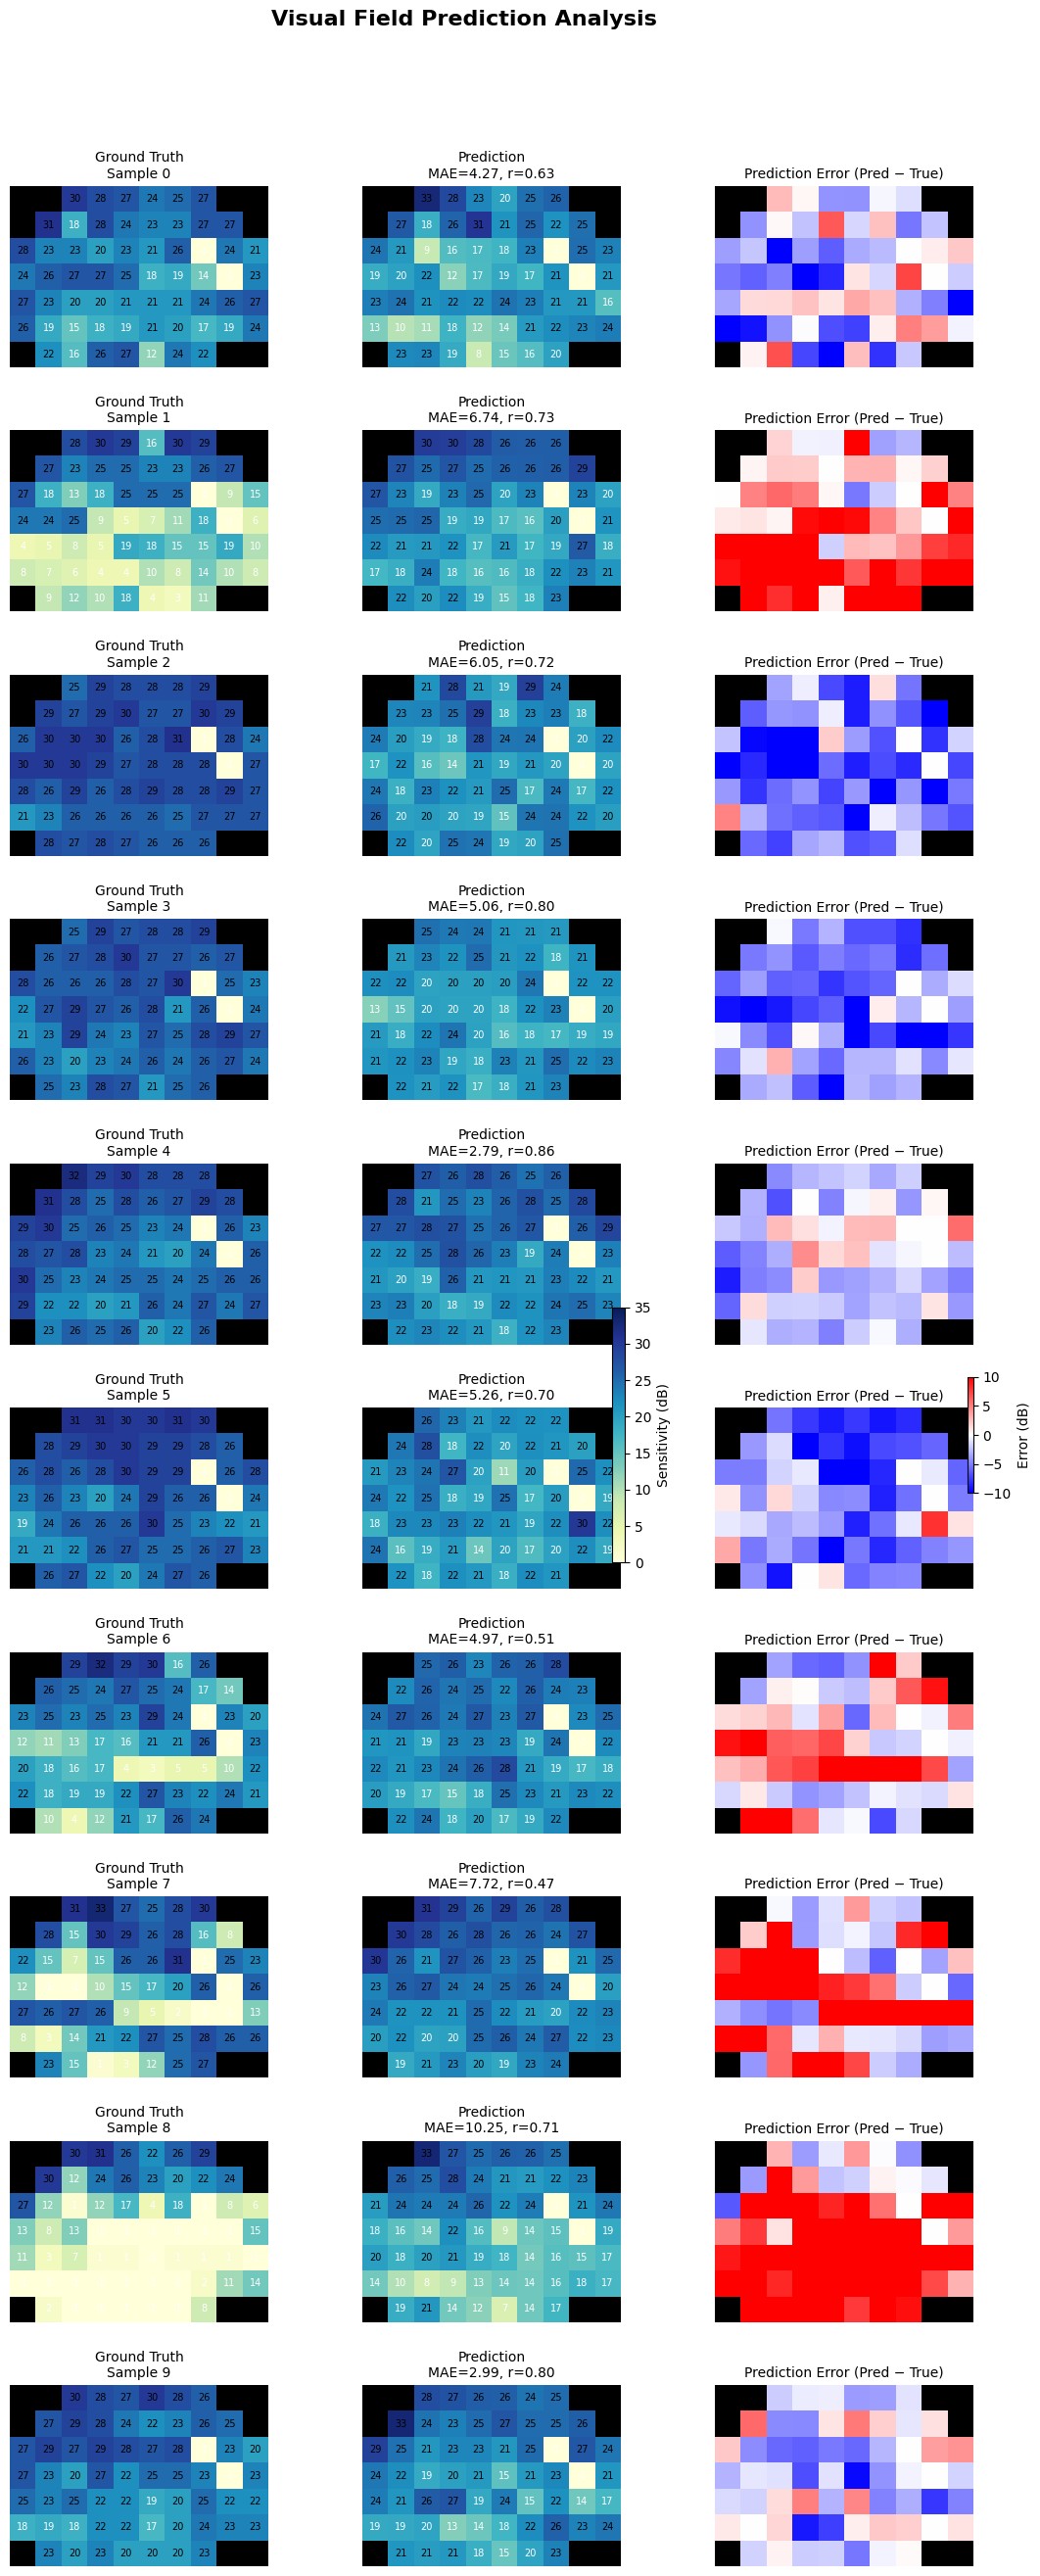

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# VF grid layout
vf_grid = np.array([
    [np.nan,np.nan,0,1,2,3,4,5,np.nan,np.nan],
    [np.nan,6,7,8,9,10,11,12,13,np.nan],
    [14,15,16,17,18,19,20,21,22,23],
    [24,25,26,27,28,29,30,31,32,33],
    [34,35,36,37,38,39,40,41,42,43],
    [44,45,46,47,48,49,50,51,52,53],
    [np.nan,54,55,56,57,58,59,60,np.nan,np.nan]
])

vf_grid_int = np.nan_to_num(vf_grid, nan=-1).astype(int)

n_show = min(10, len(all_true))

if n_show == 0:
    raise ValueError("No predictions available. Run run_test() first.")

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3*n_show))

if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

# colormaps
cmap_vf = plt.cm.YlGnBu.copy()
cmap_vf.set_bad(color='black')

cmap_err = plt.cm.bwr.copy()
cmap_err.set_bad(color='black')

for row in range(n_show):

    true_vf = np.full(vf_grid.shape, np.nan)
    pred_vf = np.full(vf_grid.shape, np.nan)
    err_vf  = np.full(vf_grid.shape, np.nan)

    for i in range(cfg.VF_DIM):
        loc = np.where(vf_grid_int == i)

        true_vf[loc] = all_true[row][i]
        pred_vf[loc] = all_pred[row][i]
        err_vf[loc]  = all_pred[row][i] - all_true[row][i]

    # ---------------- Ground Truth ----------------
    im1 = axes[row,0].imshow(true_vf, cmap=cmap_vf, vmin=0, vmax=35)
    axes[row,0].set_title(f"Ground Truth\nSample {row}", fontsize=10)

    for y in range(true_vf.shape[0]):
        for x in range(true_vf.shape[1]):

            if not np.isnan(true_vf[y,x]):

                color = "white" if true_vf[y,x] < 20 else "black"

                axes[row,0].text(
                    x, y,
                    f"{true_vf[y,x]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=color
                )

    # ---------------- Prediction ----------------
    im2 = axes[row,1].imshow(pred_vf, cmap=cmap_vf, vmin=0, vmax=35)

    axes[row,1].set_title(
        f"Prediction\nMAE={results[row]['mae']:.2f}, r={results[row]['pearson_r']:.2f}",
        fontsize=10
    )

    for y in range(pred_vf.shape[0]):
        for x in range(pred_vf.shape[1]):

            if not np.isnan(pred_vf[y,x]):

                color = "white" if pred_vf[y,x] < 20 else "black"

                axes[row,1].text(
                    x, y,
                    f"{pred_vf[y,x]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=color
                )

    # ---------------- Error Map ----------------
    im3 = axes[row,2].imshow(err_vf, cmap=cmap_err, vmin=-10, vmax=10)
    axes[row,2].set_title("Prediction Error (Pred − True)", fontsize=10)

    for ax in axes[row]:
        ax.axis("off")

# colorbars
cbar1 = fig.colorbar(im2, ax=axes[:,0:2], fraction=0.02, pad=0.02)
cbar1.set_label("Sensitivity (dB)")

cbar2 = fig.colorbar(im3, ax=axes[:,2], fraction=0.02, pad=0.02)
cbar2.set_label("Error (dB)")

plt.suptitle("Visual Field Prediction Analysis", fontsize=16, fontweight="bold")

plt.subplots_adjust(top=0.92, wspace=0.25, hspace=0.35)

plt.savefig(Path(cfg.RESULTS_DIR) / "vf_prediction_analysis.png", dpi=200)

plt.show()


### Metric Distributions

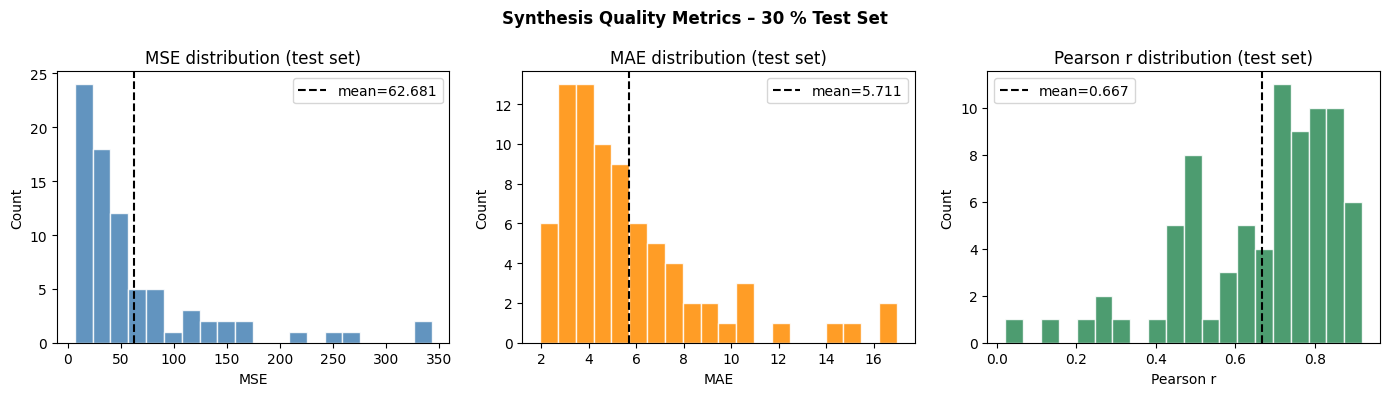

In [29]:
mses  = [r["mse"]  for r in results]
maes  = [r["mae"]  for r in results]
rs    = [float(r["pearson_r"]) for r in results if r["pearson_r"] != "nan"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, vals, title, colour in zip(
        axes,
        [mses,        maes,         rs],
        ["MSE",       "MAE",        "Pearson r"],
        ["steelblue", "darkorange", "seagreen"]):
    ax.hist(vals, bins=20, color=colour, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(vals), color="black", lw=1.5, linestyle="--",
               label=f"mean={np.mean(vals):.3f}")
    ax.set_title(f"{title} distribution (test set)")
    ax.set_xlabel(title); ax.set_ylabel("Count"); ax.legend()

plt.suptitle("Synthesis Quality Metrics – 30 % Test Set",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(Path(cfg.RESULTS_DIR) / "metric_histograms.png", dpi=150)
plt.show()


### Results preview (first 10 rows of CSV)

In [30]:
df_results = pd.read_csv(Path(cfg.RESULTS_DIR) / "test_synthesis_results.csv")
display(df_results[["sample_idx","excel_row","image_file",
                     "mse","mae","rmse","pearson_r"]].head(10))


,sample_idx,excel_row,image_file,mse,mae,rmse,pearson_r
0,0,118,68_OD_1.jpg,33.104958,4.270638,5.753691,0.629224
1,1,123,71_OD_1.jpg,76.039238,6.739081,8.720048,0.725322
2,2,262,143_OD_1.jpg,48.885788,6.052295,6.991837,0.723196
3,3,229,126_OS_1.jpg,34.656605,5.064145,5.886986,0.797919
4,4,69,42_OS_1.jpg,11.320743,2.790275,3.364631,0.862209
5,5,252,138_OD_1.jpg,39.840961,5.260272,6.311970,0.703480
6,6,179,100_OD_1.jpg,52.940357,4.966902,7.276012,0.509662
7,7,219,121_OD_1.jpg,112.133240,7.721406,10.589298,0.467317
8,8,12,8_OD_1.jpg,147.549667,10.248772,12.147002,0.707216
9,9,104,60_OS_1.jpg,14.653824,2.990279,3.828031,0.802822


## Section 6 – Free Inference (Single New Image)

Use this cell to synthesise a VF for **any new fundus image** that was not part of the dataset.  
Set the four variables below and run.


DDPM reverse sampling:   0%|          | 0/300 [00:00<?, ?it/s]

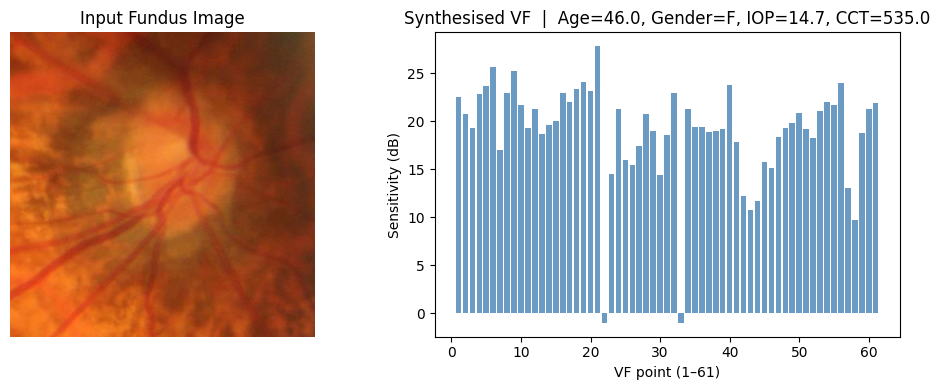


Synthesised Visual Field (61 points):
  VF[ 1] =   22.514
  VF[ 2] =   20.746
  VF[ 3] =   19.311
  VF[ 4] =   22.836
  VF[ 5] =   23.718
  VF[ 6] =   25.627
  VF[ 7] =   17.042
  VF[ 8] =   22.966
  VF[ 9] =   25.229
  VF[10] =   21.712
  VF[11] =   19.258
  VF[12] =   21.236
  VF[13] =   18.655
  VF[14] =   19.566
  VF[15] =   20.002
  VF[16] =   22.952
  VF[17] =   22.062
  VF[18] =   23.331
  VF[19] =   24.147
  VF[20] =   23.198
  VF[21] =   27.830
  VF[22] =   -1.000
  VF[23] =   14.525
  VF[24] =   21.280
  VF[25] =   16.022
  VF[26] =   15.454
  VF[27] =   17.437
  VF[28] =   20.767
  VF[29] =   19.042
  VF[30] =   14.373
  VF[31] =   18.583
  VF[32] =   22.989
  VF[33] =   -1.000
  VF[34] =   21.314
  VF[35] =   19.383
  VF[36] =   19.396
  VF[37] =   18.849
  VF[38] =   18.942
  VF[39] =   19.201
  VF[40] =   23.749
  VF[41] =   17.821
  VF[42] =   12.260
  VF[43] =   10.726
  VF[44] =   11.690
  VF[45] =   15.777
  VF[46] =   15.176
  VF[47] =   18.388
  VF[48] =   19.355
 

In [35]:
# ── User inputs ──────────────────────────────────────────────────────────────
INFER_IMAGE  =  str(cfg.IMAGE_DIR / "1_OD_1.jpg")   # path to fundus image
INFER_AGE    = 46.0
INFER_GENDER = "F"          # "F" or "M"
INFER_IOP    = 14.7
INFER_CCT    = 535.0
# ─────────────────────────────────────────────────────────────────────────────

def infer_single(image_path, age, gender, iop, cct, ckpt_path=None):
    device    = torch.device(cfg.DEVICE)
    ckpt_path = ckpt_path or str(Path(cfg.CHECKPOINT_DIR) / "best_model.pt")

    ckpt = torch.load(
      ckpt_path,
      map_location=device,
      weights_only=False
    )
    model = CDPMVFSynthesizer().to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    schedule  = DiffusionSchedule().to(device)
    vf_mean   = np.array(ckpt["vf_mean"],   dtype=np.float32)
    vf_std    = np.array(ckpt["vf_std"],    dtype=np.float32)
    clin_mean = np.array(ckpt["clin_mean"], dtype=np.float32)
    clin_std  = np.array(ckpt["clin_std"],  dtype=np.float32)

    # Preprocess image
    tfm = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")

    # Show the input image
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title("Input Fundus Image"); axes[0].axis("off")

    img_t = tfm(img).unsqueeze(0).to(device)

    # Preprocess clinical
    gender_val = 1.0 if str(gender).upper().startswith("F") else 0.0
    clin_raw   = np.array([age, gender_val, iop, cct], dtype=np.float32)
    clin_t     = torch.tensor((clin_raw - clin_mean) / clin_std,
                               dtype=torch.float32).unsqueeze(0).to(device)

    # Synthesise
    with torch.no_grad():
        cond      = model.encode(img_t, clin_t)
        synth_norm = ddpm_reverse_sample(model, schedule, cond, device)
    synth_vf = synth_norm.cpu().numpy().squeeze() * vf_std + vf_mean

    # Plot synthesised VF
    axes[1].bar(np.arange(1, cfg.VF_DIM + 1), synth_vf, color="steelblue", alpha=0.8)
    axes[1].set_xlabel("VF point (1–61)"); axes[1].set_ylabel("Sensitivity (dB)")
    axes[1].set_title(f"Synthesised VF  |  Age={age}, Gender={gender}, "
                      f"IOP={iop}, CCT={cct}")
    plt.tight_layout(); plt.show()

    print("\nSynthesised Visual Field (61 points):")
    for i, v in enumerate(synth_vf):
        print(f"  VF[{i+1:2d}] = {v:8.3f}")
    return synth_vf

synth_vf = infer_single(INFER_IMAGE, INFER_AGE, INFER_GENDER, INFER_IOP, INFER_CCT)
